# Challenges in Developing Great QMC Software

Original QMCPy demo: [`QMCPy/demos/talk_paper_demos/MCQMC2022_Article_Figures/MCQMC2022_Article_Figures.ipynb`](../../../../QMCPy/demos/talk_paper_demos/MCQMC2022_Article_Figures/MCQMC2022_Article_Figures.ipynb)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/QMCSoftware/QMC.jl/blob/develop/demos/talk_paper_demos/MCQMC2022_Article_Figures/MCQMC2022_Article_Figures.ipynb)

Computations and figures for the MCQMC 2022 article *Challenges in Developing Great Quasi-Monte Carlo Software*. This Julia translation ports the lattice-point visualization section. The beam-propagation example requires a Docker/UMBridge server and pre-computed pickle files; see [`demos/umbridge.ipynb`](../../umbridge.ipynb) for the Julia UMBridge integration demo.

Parity note: this Julia notebook keeps the overlapping low-discrepancy lattice-point figures aligned with QMCPy, while QMCPy's `Beam Example Plots` and `Beam Example Computations` sections remain split because they require Docker-backed UM-Bridge runs and external `ld_parallel.pkl` and `iid_ld.pkl` archives that are not tracked here.


## Import the necessary packages and set up plotting routines


### Make sure that you have the relevant path to store the figures

This Julia version writes figures only when plotting support is available. Otherwise it keeps the corresponding numerical summaries inline so the notebook remains self-contained in CI.


In [1]:
using QMC
using Printf
using Statistics

const HAVE_PLOTS = Base.find_package("Plots") !== nothing
HAVE_PLOTS && @eval using Plots
if HAVE_PLOTS
    Plots.default(
        titlefont=Plots.font(9),
        plot_titlefont=Plots.font(11),
        left_margin=4Plots.mm,
        right_margin=8Plots.mm,
        top_margin=8Plots.mm,
        bottom_margin=5Plots.mm,
    )
end


## Here are some plots of Low Discrepancy (LD) Lattice Points

The Python notebook visualizes how a shifted lattice fills $[0,1]^2$ progressively: the first $n=32$ points are shown in one color, the next batch in a second color, and so on. The same progressive structure is reproduced below using a `Lattice` generator.


In [2]:
d = 2
lattice = Lattice(d; seed=7)
# Generate enough points to show three batches: 32, then 32 more, then 64 more = 128 total
n_total = 128
x = gen_samples(lattice, n_total)
@printf("Generated %d lattice points in d=%d dimensions\n", n_total, d)
@printf("Column means: (%.4f, %.4f) — ideal 0.5\n", mean(x[:, 1]), mean(x[:, 2]))

@assert size(x) == (n_total, d)
@assert all(0 .<= x .< 1)


Generated 128 lattice points in d=2 dimensions
Column means: (0.5029, 0.5027) — ideal 0.5


In [3]:
# Show the first 32 points and the progressive batches numerically
batches = [(1, 32, "first 32"), (33, 64, "next 32"), (65, 128, "final 64")]
for (lo, hi, label) in batches
    sub = x[lo:hi, :]
    @printf("  %s: mean=(%.4f, %.4f)\n", label, mean(sub[:, 1]), mean(sub[:, 2]))
end


  first 32: mean=(0.5146, 0.5066)
  next 32: mean=(0.4990, 0.4910)
  final 64: mean=(0.4990, 0.5066)


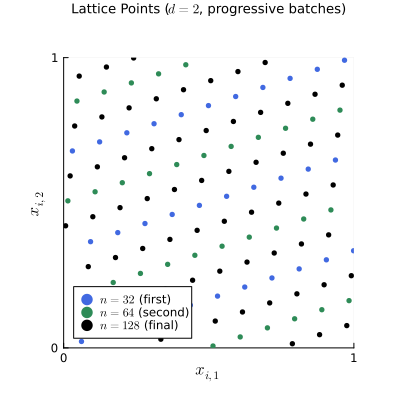

In [4]:
if HAVE_PLOTS
    batch_colors  = [:royalblue, :seagreen, :black]
    batch_labels  = ["\$n=32\$ (first)", "\$n=64\$ (second)", "\$n=128\$ (final)"]
    batch_ranges  = [1:32, 33:64, 65:128]
    p = plot(; title="Lattice Points (\$d=2\$, progressive batches)",
               xlabel="\$x_{i,1}\$", ylabel="\$x_{i,2}\$",
               xlims=(0,1), ylims=(0,1), aspect_ratio=:equal,
               xticks=[0,1], yticks=[0,1], size=(400,420))
    for (rng, col, lab) in zip(batch_ranges, batch_colors, batch_labels)
        scatter!(p, x[rng, 1], x[rng, 2]; color=col, label=lab,
                 markersize=3, markerstrokewidth=0)
    end
    display(p)
end


The three batches tile the unit square with increasing density, illustrating the extensible low-discrepancy property of lattice rules: each new batch fills the gaps left by the previous one.


## Beam Example Plots

### Plot the time and sample size required to solve for the deflection of the whole beam using low discrepancy with and without parallel

### Plot of beam solution

The Python notebook's beam-example plotting sections rely on external `ld_parallel.pkl` and `iid_ld.pkl` archives that are not tracked here.

## Beam Example Computations

### Set up the problem using a docker container to solve the ODE

### First we compute the time required to solve for the deflection of the end point using IID and low discrepancy

### Next, we compute the time required to solve for the deflection of the whole beam using low discrepancy with and without parallel

Those sections also require a running **Docker** container exposing the MUQ beam-propagation benchmark on port 4243. Neither artifact ships with this repository. For a self-contained QMC.jl demo that connects to a UMBridge model, see [`demos/umbridge.ipynb`](../../umbridge.ipynb).
